# Portfolio VaR & ES — Notebook 01: Data Loading & Cleaning, Portfolio Weights

**Course**: Quantitative Financial Risk Management — Charles Bos (2026/3)  
**Group**: [Your Group Name]

---

### Notebook Map
| Notebook | Tasks | Content |
|---|---|---|
| 01_data_pipeline.ipynb | Task 1 & 2 | Data import, cleaning, returns, portfolio weights |
| 02_univariate_var.ipynb | Task 3 | EDA, QQ-plots, univariate VaR & ES per asset |
| 03_portfolio_var.ipynb | Task 4 | Portfolio-level VaR & ES (all 5 methods) |
| 04_backtesting.ipynb | Task 5 | Backtesting, violation counts, dependence |
| 05_multiday_var.ipynb | Task 6 | 1, 5, 10-day VaR, square-root-of-time comparison |
| 06_stress_testing.ipynb | Task 7 | Stress testing, shock scenarios |



---
## For Other Noteboks

In [95]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import minimize
warnings.filterwarnings("ignore")

# Data paths 
DATA_RAW     = "data/data_real.xlsx"
DATA_PRICES  = "data/prices_clean.csv"
DATA_RETURNS = "data/returns_clean.csv"

STOCKS   = ["ASML", "SHELL", "JPM"]
INDEX    = ["STOXX50", "SP500"]
FX       = ["EURUSD"]
RATE     = ["EURIBOR3M"]
RISKY    = STOCKS + INDEX
ALL_COLS = STOCKS + INDEX + FX + RATE

# ── Time periods ──────────────────────────────────────────────────────────────
PRE_START    = "2015-01-01"
PRE_END      = "2016-12-31"
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio ─────────────────────────────────────────────────────────────────
PORTFOLIO_VALUE = 1_000_000
LOAN_WEIGHT     = 0.20        # two-fund split: 20% bond, 80% tangency portfolio
RISKY_WEIGHT    = 0.80
WEIGHT_MIN      = 0.05
WEIGHT_MAX      = 0.40
LOAN_SPREAD_BPS = 150
TRADING_DAYS    = 252

# ── Populated after running Section 4 — paste output back in ─────────────────
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.178207,
    "SHELL": 0.040000,
    "JPM": 0.320000,
    "STOXX50": 0.040000,
    "SP500": 0.221793,
    "LOAN": 0.200000,
}

---
## 1. Imports


In [96]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import minimize

warnings.filterwarnings("ignore")


# Equity & FX 
equity_tickers = ["ASML.AS", "JPM", "SHELL.AS", "^GSPC", "^STOXX50E", "EURUSD=X"]

raw_equity = yf.download(
    equity_tickers, start=PRE_START, end=SAMPLE_END, auto_adjust=True
)["Close"]

raw_equity = raw_equity.rename(columns={
    "ASML.AS": "ASML",
    "SHELL.AS": "SHELL",
    "^GSPC": "SP500",
    "^STOXX50E": "STOXX50",
    "EURUSD=X": "EURUSD",
})

# EURIBOR 3M from attached CSV
csv_path = "data/EURIBOR3m.csv"

euribor_raw = pd.read_csv(csv_path, header=None)

# keep only rows where first column looks like a date
date_mask = pd.to_datetime(euribor_raw[0], errors="coerce").notna()
euribor = euribor_raw.loc[date_mask, [0, 1]].copy()

euribor.columns = ["Date", "EURIBOR3M"]
euribor["Date"] = pd.to_datetime(euribor["Date"])
euribor["EURIBOR3M"] = pd.to_numeric(
    euribor["EURIBOR3M"].replace(".", pd.NA), errors="coerce"
)

euribor = euribor.set_index("Date").sort_index()
euribor = euribor.loc[PRE_START:SAMPLE_END]

# Merge on trading dates
data = raw_equity.join(euribor, how="left")

data.to_excel("data/data_real.xlsx")

[*********************100%***********************]  6 of 6 completed


---
## 2. Configuration

In [97]:
prices = pd.read_excel(DATA_RAW, index_col=0, parse_dates=True)
prices = prices[ALL_COLS]

print(f"Shape     : {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nRaw NaN counts:\n{prices.isnull().sum().to_string()}")


Shape     : (2929, 7)
Date range: 2015-01-01 → 2026-03-30

Raw NaN counts:
ASML          52
SHELL         52
JPM          103
STOXX50      105
SP500        103
EURUSD         4
EURIBOR3M     50


---
## 3. Cleaning

In [98]:

# missing value summary
daily_missing = prices.isnull().sum(axis=1)
print("Missing assets per day:")
print(daily_missing.value_counts().sort_index().to_string())

# drop rows with 4 or more missing assets (confirmed market closures)
prices_clean = prices.copy()
drop_mask = prices_clean.isnull().sum(axis=1) >= 4
prices_clean = prices_clean[~drop_mask]
print(f"\nRows dropped: {drop_mask.sum()}")

# gap lengths after drop
print("\nNaN counts and max consecutive gap after drop:")
for col in ALL_COLS:
    s = prices_clean[col]
    total = s.isnull().sum()
    max_gap = max((sum(1 for _ in g) for v, g in itertools.groupby(s.isnull()) if v), default=0)
    print(f"  {col:12s}  nans: {total:3d}  max_gap: {max_gap}")

# forward-fill remaining gaps
prices_clean["EURIBOR3M"]         = prices_clean["EURIBOR3M"].ffill()
prices_clean[STOCKS + INDEX + FX] = prices_clean[STOCKS + INDEX + FX].ffill()

# back-fill opening row edge case
prices_clean = prices_clean.bfill(limit=1)

assert prices_clean.isnull().sum().sum() == 0, "NaNs remain after filling"
print(f"\nClean prices shape: {prices_clean.shape}")

# check no large returns coincide with filled dates
ffill_dates  = prices.index[prices[STOCKS + INDEX + FX].isnull().any(axis=1)]
filled_dates = ffill_dates.union(pd.DatetimeIndex(["2015-01-02"]))

log_ret = np.log(prices_clean[STOCKS + INDEX + FX] / prices_clean[STOCKS + INDEX + FX].shift(1))
hits    = log_ret[log_ret.abs() > 0.075].stack().reset_index()
hits.columns = ["Date", "Asset", "Return"]

overlap = pd.DatetimeIndex(hits["Date"].values).intersection(filled_dates)
print(f"\nFilled dates:      {len(filled_dates)}")
print(f"Large return days: {len(hits)}")
print(f"Overlap:           {len(overlap)}")

# save
prices_clean.to_csv(DATA_PRICES)
print(f"\nSaved: {DATA_PRICES}")

Missing assets per day:
0    2749
1      51
2      72
3       7
4      23
5       1
6      26

Rows dropped: 50

NaN counts and max consecutive gap after drop:
  ASML          nans:   2  max_gap: 1
  SHELL         nans:   2  max_gap: 1
  JPM           nans:  77  max_gap: 1
  STOXX50       nans:  55  max_gap: 2
  SP500         nans:  77  max_gap: 1
  EURUSD        nans:   3  max_gap: 1
  EURIBOR3M     nans:   0  max_gap: 0

Clean prices shape: (2879, 7)

Filled dates:      180
Large return days: 56
Overlap:           0

Saved: data/prices_clean.csv


---
## 4. Portfolio 

**Computing Returns and Variances**

In [99]:
# ── Returns ───────────────────────────────────────────────────────────────────
returns = pd.DataFrame(index=prices_clean.index)

for col in RISKY + FX:
    returns[col] = np.log(prices_clean[col] / prices_clean[col].shift(1))

returns["EURIBOR3M"] = prices_clean["EURIBOR3M"].diff()
returns = returns.dropna(how="all")

# ── Pre-sample covariance (risky only, no look-ahead bias) ────────────────────
ret_pre    = returns.loc[PRE_START:PRE_END, RISKY].dropna()
ret_sample = returns.loc[SAMPLE_START:SAMPLE_END]
Sigma_pre  = ret_pre.cov()
Sigma_full = returns.loc[SAMPLE_START:SAMPLE_END, RISKY].dropna().cov()

print(f"Pre-sample obs : {len(ret_pre)}")
print(f"Main sample obs: {len(ret_sample)}")
print(f"\n{'Asset':10s}  {'Pre (%)':>8}  {'Full (%)':>8}  {'Ratio':>6}")
for col in RISKY:
    v_pre  = np.sqrt(Sigma_pre.loc[col, col]  * TRADING_DAYS) * 100
    v_full = np.sqrt(Sigma_full.loc[col, col] * TRADING_DAYS) * 100
    print(f"{col:10s}  {v_pre:>8.2f}  {v_full:>8.2f}  {v_full/v_pre:>6.2f}")


Pre-sample obs : 512
Main sample obs: 2366

Asset        Pre (%)  Full (%)   Ratio
ASML           29.55     34.45    1.17
SHELL          29.54     28.57    0.97
JPM            23.27     27.61    1.19
STOXX50        22.41     18.03    0.80
SP500          14.25     18.33    1.29


**Mean-Variance Optimisation**

In [100]:

# ── Optimisation (pre-sample, no look-ahead bias) ─────────────────────────────
n   = len(RISKY)
S   = Sigma_pre.values * TRADING_DAYS       # annualised covariance
mu  = ret_pre.mean().values * TRADING_DAYS  # annualised expected returns
rf  = EURIBOR_T0 / 100                      # risk-free rate (decimal p.a.)

bounds      = [(WEIGHT_MIN, WEIGHT_MAX)] * n
constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
x0          = np.ones(n) / n

# min-variance (kept for diagnostic / efficient frontier plot)
res_minvar = minimize(
    fun=lambda w: w @ S @ w,
    x0=x0, method="SLSQP", bounds=bounds, constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
assert res_minvar.success, f"Min-var failed: {res_minvar.message}"
w_minvar = res_minvar.x

# tangency portfolio (max Sharpe) — used for two-fund allocation
res_tangent = minimize(
    fun=lambda w: -(w @ mu - rf) / np.sqrt(w @ S @ w),
    x0=x0, method="SLSQP", bounds=bounds, constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
assert res_tangent.success, f"Tangency failed: {res_tangent.message}"
w_tangent = res_tangent.x

print(f"\n{'Asset':10s}  {'MinVar w':>9}  {'Tangent w':>9}")
for i, col in enumerate(RISKY):
    print(f"{col:10s}  {w_minvar[i]:>9.4f}  {w_tangent[i]:>9.4f}")

# ── Two-fund separation: 80% tangency + 20% fixed-rate bond ──────────────────
weights_risky = dict(zip(RISKY, np.round(w_tangent, 6)))
WEIGHTS = {k: round(v * RISKY_WEIGHT, 6) for k, v in weights_risky.items()}
WEIGHTS["LOAN"] = LOAN_WEIGHT

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-6, "Weights do not sum to 1"


Asset        MinVar w  Tangent w
ASML           0.0787     0.2228
SHELL          0.0500     0.0500
JPM            0.1846     0.4000
STOXX50        0.2868     0.0500
SP500          0.4000     0.2772


In [101]:

# ── Loan parameters (fixed-rate: coupon locked at EURIBOR_t0 + spread) ────────
EURIBOR_T0    = prices_clean.loc["2017-01-03", "EURIBOR3M"]
LOAN_COUPON   = EURIBOR_T0 / 100 + LOAN_SPREAD_BPS / 10_000
LOAN_MATURITY = (pd.Timestamp(SAMPLE_END) - pd.Timestamp(SAMPLE_START)).days / 365.25
LOAN_MOD_DUR  = LOAN_MATURITY / (1 + LOAN_COUPON)   # fixed-rate duration

# ── Loan daily return: coupon accrual − duration × rate move ──────────────────
# EURIBOR3M return is Δ percentage points → divide by 100 for decimal
DAILY_COUPON      = LOAN_COUPON / TRADING_DAYS
returns["LOAN"]   = DAILY_COUPON - LOAN_MOD_DUR * (returns["EURIBOR3M"] / 100)

# ── Print results ─────────────────────────────────────────────────────────────
print(f"\n{'Asset':10s}  {'Weight':>8}  {'Notional (EUR)':>15}")
for k, v in WEIGHTS.items():
    print(f"{k:10s}  {v:>8.4f}  {v * PORTFOLIO_VALUE:>15,.0f}")

vol_risky = np.sqrt(w_tangent @ S @ w_tangent)
ret_risky = w_tangent @ mu
sharpe    = (ret_risky - rf) / vol_risky
print(f"\nTangency portfolio:  ret={ret_risky*100:.2f}%  vol={vol_risky*100:.2f}%  Sharpe={sharpe:.3f}")
print(f"Loan (fixed-rate):   coupon={LOAN_COUPON*100:.4f}%  "
      f"maturity={LOAN_MATURITY:.4f}y  mod_dur={LOAN_MOD_DUR:.4f}y")
print(f"  → DV01 on notional: €{LOAN_MOD_DUR * LOAN_WEIGHT * PORTFOLIO_VALUE / 10_000:,.1f} per bp")

# ── Save returns (now includes LOAN column) ───────────────────────────────────
returns.to_csv(DATA_RETURNS)
print(f"\nSaved: {DATA_RETURNS}  (columns: {list(returns.columns)})")

# ── Paste into Section 2 config cell ─────────────────────────────────────────
print("\n# ── Paste into Section 2 config cell ───────────────────────────────")
print(f"EURIBOR_T0    = {EURIBOR_T0:.6f}")
print(f"LOAN_COUPON   = {LOAN_COUPON:.6f}")
print(f"LOAN_MATURITY = {LOAN_MATURITY:.6f}")
print(f"LOAN_MOD_DUR  = {LOAN_MOD_DUR:.6f}   # fixed-rate duration")
print("WEIGHTS = {")
for k, v in WEIGHTS.items():
    print(f'    "{k}": {v:.6f},')
print("}")



Asset         Weight   Notional (EUR)
ASML          0.1782          178,207
SHELL         0.0400           40,000
JPM           0.3200          320,000
STOXX50       0.0400           40,000
SP500         0.2218          221,793
LOAN          0.2000          200,000

Tangency portfolio:  ret=11.03%  vol=18.19%  Sharpe=0.624
Loan (fixed-rate):   coupon=1.1810%  maturity=9.2430y  mod_dur=9.1351y
  → DV01 on notional: €182.7 per bp

Saved: data/returns_clean.csv  (columns: ['ASML', 'SHELL', 'JPM', 'STOXX50', 'SP500', 'EURUSD', 'EURIBOR3M', 'LOAN'])

# ── Paste into Section 2 config cell ───────────────────────────────
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.178207,
    "SHELL": 0.040000,
    "JPM": 0.320000,
    "STOXX50": 0.040000,
    "SP500": 0.221793,
    "LOAN": 0.200000,
}


**Efficient Frontier**

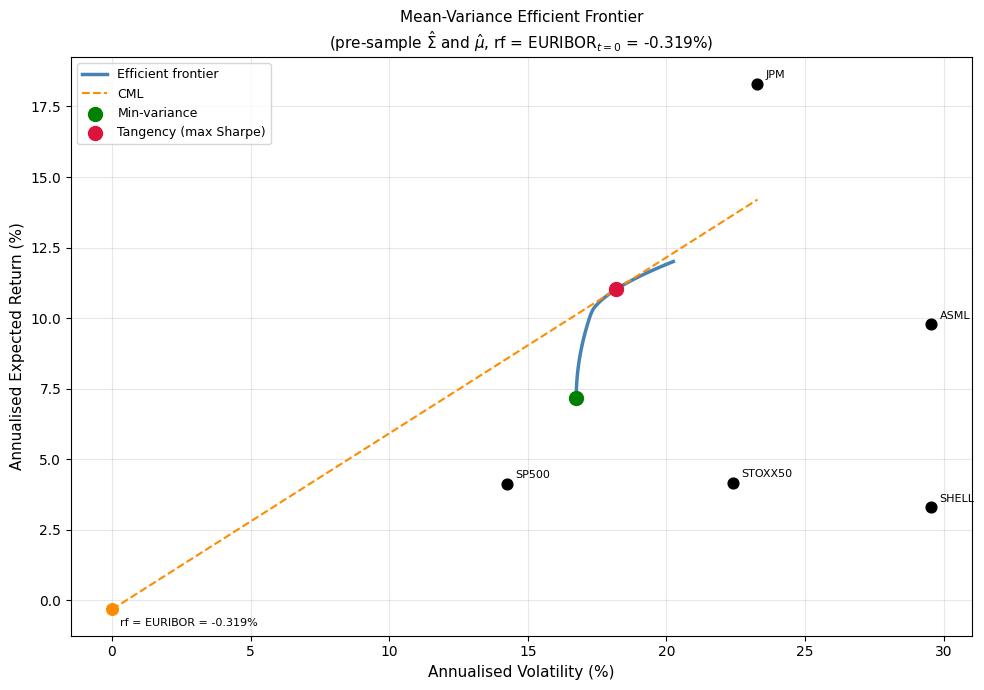

In [ ]:
# ── Efficient frontier ────────────────────────────────────────────────────────
target_rets = np.linspace(mu_ann.min () * 0.8, mu_ann.max() * 1.1, 300)
frontier_vols, frontier_rets = [], []

for target in target_rets:
    constraints = [
        {"type": "eq", "fun": lambda w: w.sum() - 1},
        {"type": "eq", "fun": lambda w, t=target: w @ mu_ann.values - t}
    ]
    res = minimize(lambda w: w @ S @ w, x0, method="SLSQP",
                   bounds=bounds, constraints=constraints,
                   options={"ftol": 1e-12, "maxiter": 1000})
    if res.success:
        frontier_vols.append(np.sqrt(res.fun))
        frontier_rets.append(target)

frontier_vols = np.array(frontier_vols)
frontier_rets = np.array(frontier_rets)

# upper (efficient) half only
mask      = frontier_rets >= port_ret(w_minvar)
eff_vols  = frontier_vols[mask]
eff_rets  = frontier_rets[mask]

# CML from rf through tangency
vol_tan   = port_vol(w_tangent)
ret_tan   = port_ret(w_tangent)
cml_vols  = np.linspace(0, eff_vols.max() * 1.15, 200)
cml_rets  = rf_annual + ((ret_tan - rf_annual) / vol_tan) * cml_vols

# individual asset vols and returns (pre-sample)
asset_vols = np.sqrt(np.diag(S))
asset_rets = mu_ann.values

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(eff_vols * 100, eff_rets * 100,
        color="steelblue", linewidth=2.5, label="Efficient frontier")

ax.plot(cml_vols * 100, cml_rets * 100,
        color="darkorange", linewidth=1.5, linestyle="--", label="CML")

ax.scatter(asset_vols * 100, asset_rets * 100,
           color="black", s=60, zorder=5)
for i, col in enumerate(RISKY):
    ax.annotate(col, (asset_vols[i] * 100, asset_rets[i] * 100),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.scatter(port_vol(w_minvar) * 100, port_ret(w_minvar) * 100,
           color="green", s=100, zorder=6, label="Min-variance")

ax.scatter(vol_tan * 100, ret_tan * 100,
           color="crimson", s=100, zorder=6, label="Tangency (max Sharpe)")

ax.scatter(0, rf_annual * 100, color="darkorange", s=70, zorder=6)
ax.annotate(f"rf = EURIBOR = {rf_annual*100:.3f}%", (0, rf_annual * 100),
            textcoords="offset points", xytext=(6, -12), fontsize=8)

ax.set_xlabel("Annualised Volatility (%)", fontsize=11)
ax.set_ylabel("Annualised Expected Return (%)", fontsize=11)
ax.set_title(
    "Mean-Variance Efficient Frontier\n"
    r"(pre-sample $\hat{\Sigma}$ and $\hat{\mu}$, "
    f"rf = EURIBOR$_{{t=0}}$ = {rf_annual*100:.3f}%)",
    fontsize=11
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Plots

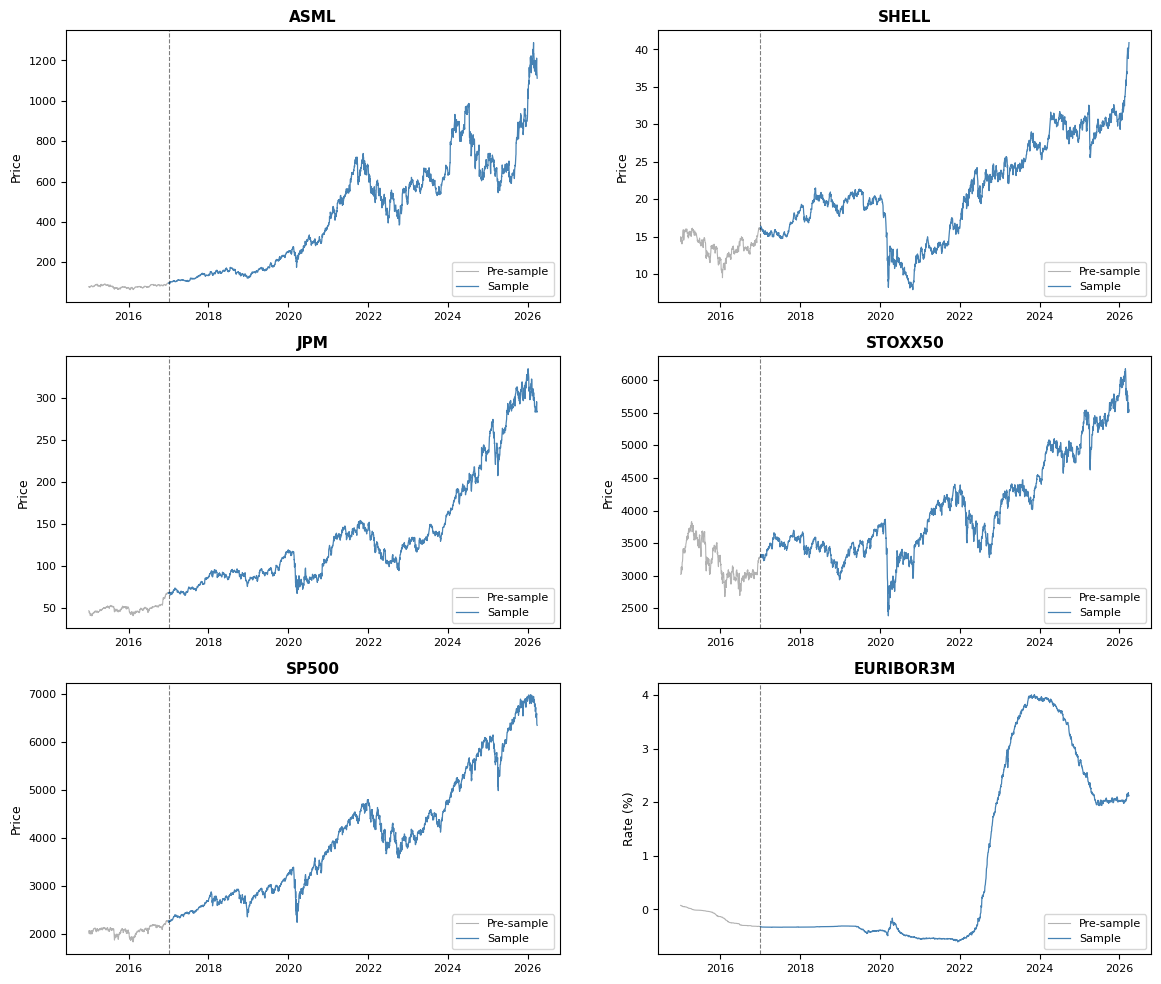

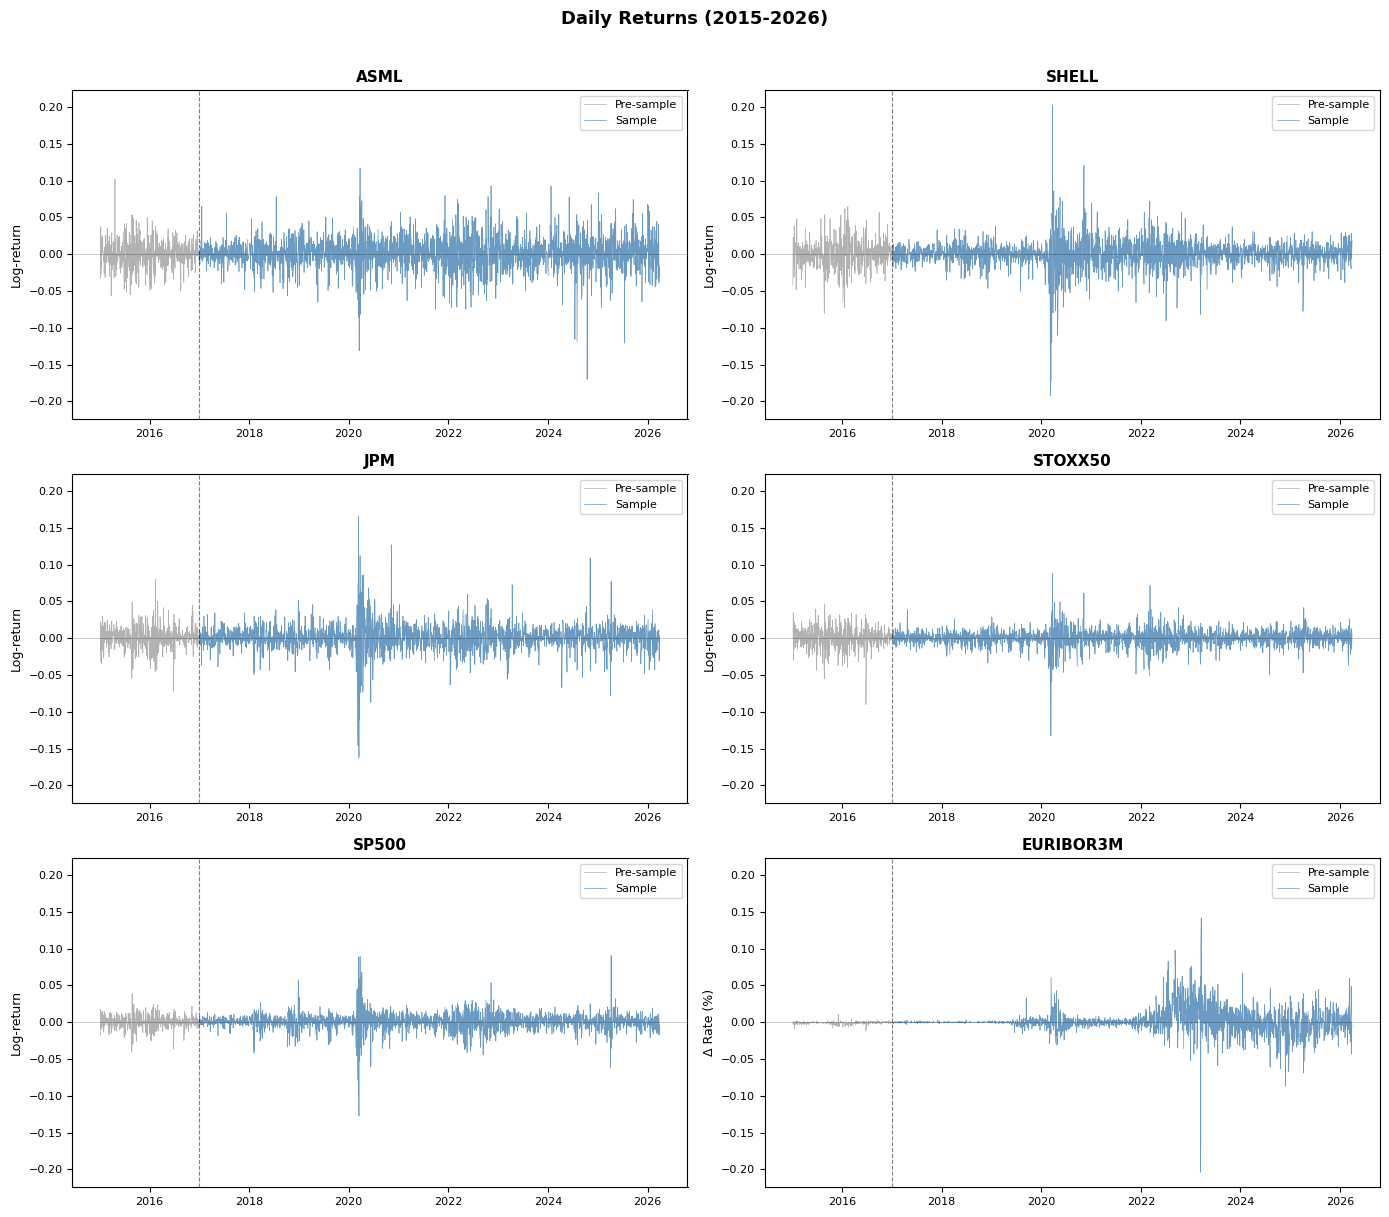

In [103]:
# ── Prices (RISKY + EURIBOR) ──────────────────────────────────────────────────
PLOT_ASSETS = RISKY + RATE   # 6 assets — fills the 3×2 grid exactly

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(PLOT_ASSETS):
    ax = axes[i]
    ax.plot(prices_clean.loc[PRE_START:PRE_END, col],
            color="grey", linewidth=0.8, alpha=0.6, label="Pre-sample")
    ax.plot(prices_clean.loc[SAMPLE_START:SAMPLE_END, col],
            color="steelblue", linewidth=0.9, label="Sample")
    ax.axvline(pd.Timestamp(SAMPLE_START), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Price" if col != "EURIBOR3M" else "Rate (%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)

# ── Returns (RISKY + EURIBOR, shared y-axis) ──────────────────────────────────
# compute global y-limits across all assets
all_returns = [returns.loc[PRE_START:SAMPLE_END, col].dropna() for col in PLOT_ASSETS]
global_min  = min(r.min() for r in all_returns)
global_max  = max(r.max() for r in all_returns)
pad         = (global_max - global_min) * 0.05   # 5% padding
ylim        = (global_min - pad, global_max + pad)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(PLOT_ASSETS):
    ax = axes[i]
    ax.plot(returns.loc[PRE_START:PRE_END, col],
            color="grey", linewidth=0.5, alpha=0.6, label="Pre-sample")
    ax.plot(returns.loc[SAMPLE_START:SAMPLE_END, col],
            color="steelblue", linewidth=0.5, alpha=0.8, label="Sample")
    ax.axvline(pd.Timestamp(SAMPLE_START), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
    ax.set_ylim(ylim)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Log-return" if col != "EURIBOR3M" else "Δ Rate (%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)

plt.suptitle("Daily Returns (2015-2026)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/returns.png", dpi=150, bbox_inches="tight")
plt.show()

---
**Commenting List for Report**
- Choice of tickers
- Time periods and frequencies
- Data Cleaning: dropping and filling
- Portfolio Weight optimisation
- Issue with EURIBOR for 10y loan
